In [1]:
import pandas as pd
import numpy as np

# purane saalon ki file load
old = pd.read_csv("../data/raw/lodhi-2017-2023.csv")
print(old.shape)
old.head()

(2478, 26)


,_id,January-2017,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,February-2017,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,March-2017,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# saare columns ke naam
print(old.columns.tolist())

# kis column mein kitna % missing hai
print((old.isna().mean() * 100).round(1).sort_values(ascending=False))

['_id', 'January-2017', '00:00:00', '01:00:00', '02:00:00', '03:00:00', '04:00:00', '05:00:00', '06:00:00', '07:00:00', '08:00:00', '09:00:00', '10:00:00', '11:00:00', '12:00:00', '13:00:00', '14:00:00', '15:00:00', '16:00:00', '17:00:00', '18:00:00', '19:00:00', '20:00:00', '21:00:00', '22:00:00', '23:00:00']
06:00:00        25.0
07:00:00        24.9
08:00:00        24.9
09:00:00        24.2
05:00:00        24.2
04:00:00        24.0
10:00:00        23.6
03:00:00        23.5
02:00:00        23.4
01:00:00        23.0
13:00:00        22.6
11:00:00        22.5
14:00:00        22.4
19:00:00        22.4
12:00:00        22.3
20:00:00        22.3
22:00:00        22.2
17:00:00        22.0
21:00:00        22.0
23:00:00        21.8
15:00:00        21.7
18:00:00        21.6
16:00:00        21.6
00:00:00        21.6
January-2017     3.4
_id              0.0
dtype: float64


In [3]:
raw = pd.read_csv("../data/raw/lodhi-2017-2023.csv", header=None)
print(raw.shape)
raw.iloc[:40, :6]

(2479, 26)


,0,1,2,3,4,5
0,_id,January-2017,00:00:00,01:00:00,02:00:00,03:00:00
1,1,NaN,NaN,NaN,NaN,NaN
2,2,February-2017,00:00:00,01:00:00,02:00:00,03:00:00
3,3,NaN,NaN,NaN,NaN,NaN
4,4,March-2017,00:00:00,01:00:00,02:00:00,03:00:00
5,5,NaN,NaN,NaN,NaN,NaN
6,6,April-2017,00:00:00,01:00:00,02:00:00,03:00:00
7,7,NaN,NaN,NaN,NaN,NaN
8,8,May-2017,00:00:00,01:00:00,02:00:00,03:00:00
9,9,NaN,NaN,NaN,NaN,NaN


In [5]:
# header=none se pehli line bhi data ki tarah dikhegi
raw = pd.read_csv("../data/raw/lodhi-2017-2023.csv", header=None)
print(raw.shape)
raw.iloc[:40, :6]

(2479, 26)


,0,1,2,3,4,5
0,_id,January-2017,00:00:00,01:00:00,02:00:00,03:00:00
1,1,NaN,NaN,NaN,NaN,NaN
2,2,February-2017,00:00:00,01:00:00,02:00:00,03:00:00
3,3,NaN,NaN,NaN,NaN,NaN
4,4,March-2017,00:00:00,01:00:00,02:00:00,03:00:00
5,5,NaN,NaN,NaN,NaN,NaN
6,6,April-2017,00:00:00,01:00:00,02:00:00,03:00:00
7,7,NaN,NaN,NaN,NaN,NaN
8,8,May-2017,00:00:00,01:00:00,02:00:00,03:00:00
9,9,NaN,NaN,NaN,NaN,NaN


In [6]:
# pehle 2 columns (_id aur label) chhodke baaki sab numbers
vals = raw.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")
print(vals.stack().describe())

count    43859.000000
mean       184.544016
std        116.210697
min         11.000000
25%         95.000000
50%        145.000000
75%        283.000000
max       2023.000000
dtype: float64


In [9]:
# wo labels jo month header nahi hain par text hain
lab = raw.iloc[:, 1].dropna().astype(str).str.strip()
is_text = lab.str[0].str.isalpha()
is_month = pd.to_datetime(lab, format="%B-%Y", errors="coerce").notna()
print(lab[is_text & ~is_month].value_counts())

1
Year    6
Name: count, dtype: int64


In [10]:
# har din ke 24 ghante ko ek ek row bana rahe hain
recs = []
cur = None
for i in range(len(raw)):
    lab = raw.iloc[i, 1]
    if pd.isna(lab):
        continue
    s = str(lab).strip()

    # text label: month header ho to cur set, warna (jaise "Year") skip
    if s[0].isalpha():
        cur = pd.to_datetime(s, format="%B-%Y", errors="coerce")
        if pd.isna(cur):
            cur = None
        continue

    if cur is None:
        continue
    day = int(float(s))
    vals = pd.to_numeric(raw.iloc[i, 2:26], errors="coerce").values
    for h, v in enumerate(vals):
        t = cur + pd.Timedelta(days=day - 1, hours=h)
        if t.month == cur.month:      # 31 feb jaisi galat date na bane
            recs.append((t, v))

old_long = pd.DataFrame(recs, columns=["Timestamp", "value"]).set_index("Timestamp").sort_index()
print(old_long.shape, old_long.index.min(), old_long.index.max())

(55296, 1) 2017-07-01 00:00:00 2023-12-31 23:00:00


In [14]:
# Purani file ka saal-wise count, mean, max
print(
    old_long["value"]
    .groupby(old_long.index.year)
    .agg(["count", "mean", "max"])
    .round(1)
)

# 2024-25 ke PM2.5 aur PM10 ka mean
fin = pd.read_csv(
    "../data/raw/lodhi_hourly_with_weather.csv",
    index_col=0,
    parse_dates=True
)

print(
    fin[["PM2.5 (ug/m3)", "PM10 (ug/m3)"]]
    .groupby(fin.index.year)
    .mean()
    .round(1)
)

           count   mean    max
Timestamp                     
2017        1674  304.7  500.0
2018        6227  203.7  500.0
2019        6361  182.6  500.0
2020        7977  156.0  500.0
2021        5989  194.8  500.0
2022        7686  178.6  500.0
2023        7932  170.9  500.0
           PM2.5 (ug/m3)  PM10 (ug/m3)
Timestamp                             
2024                78.7         151.8
2025                86.9         183.9


In [15]:
# cpcb ke breakpoints se pm2.5 aur pm10 ka sub-index (24 ghante ka rolling mean)
pm25_24 = fin["PM2.5 (ug/m3)"].rolling(24, min_periods=16).mean()
pm10_24 = fin["PM10 (ug/m3)"].rolling(24, min_periods=16).mean()

si25 = np.interp(pm25_24, [0, 30, 60, 90, 120, 250, 380], [0, 50, 100, 200, 300, 400, 500])
si10 = np.interp(pm10_24, [0, 50, 100, 250, 350, 430, 510], [0, 50, 100, 200, 300, 400, 500])

# dono mein se jo zyada ho wahi aqi
fin["AQI"] = np.fmax(si25, si10)

In [16]:
# 2024-25 ka naya aqi
print(fin["AQI"].groupby(fin.index.year).agg(["count", "mean", "max"]).round(1))

# purane saalon ka aqi (upar jaisa)
print(old_long["value"].groupby(old_long.index.year).agg(["count", "mean", "max"]).round(1))

           count   mean    max
Timestamp                     
2024        8751  165.1  500.0
2025        7190  190.3  500.0
           count   mean    max
Timestamp                     
2017        1674  304.7  500.0
2018        6227  203.7  500.0
2019        6361  182.6  500.0
2020        7977  156.0  500.0
2021        5989  194.8  500.0
2022        7686  178.6  500.0
2023        7932  170.9  500.0


In [17]:
# purana aqi (2017-23) aur naya (2024-25) ek series mein
a_old = old_long["value"].rename("AQI")
a_new = fin["AQI"]
aqi = pd.concat([a_old, a_new]).sort_index()
aqi = aqi[~aqi.index.duplicated(keep="first")]

# poora hourly index banao, jahan data nahi wahan nan
aqi = aqi.reindex(pd.date_range(aqi.index.min(), aqi.index.max(), freq="1h"))
aqi.index.name = "Timestamp"
print(aqi.shape, aqi.index.min(), aqi.index.max())
print("missing %:", round(aqi.isna().mean() * 100, 1))

(74544,) 2017-07-01 00:00:00 2025-12-31 23:00:00
missing %: 19.8


In [18]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
frames = []

# saal ke hisaab se alag alag mangwa rahe hain, ek saath bada request fail ho sakta hai
for y in range(2017, 2026):
    start = f"{y}-07-01" if y == 2017 else f"{y}-01-01"
    params = {
        "latitude": 28.59, "longitude": 77.23,
        "start_date": start, "end_date": f"{y}-12-31",
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation",
        "timezone": "Asia/Kolkata",
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    frames.append(pd.DataFrame(r.json()["hourly"]))
    print(y, "done")

weather = pd.concat(frames)
weather["time"] = pd.to_datetime(weather["time"])
weather = weather.set_index("time")
print(weather.shape)

2017 done
2018 done
2019 done
2020 done
2021 done
2022 done
2023 done
2024 done
2025 done
(74544, 6)


(74544, 7)
AQI                     19.8
temperature_2m           0.0
relative_humidity_2m     0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
precipitation            0.0
dtype: float64


<Axes: xlabel='Timestamp'>

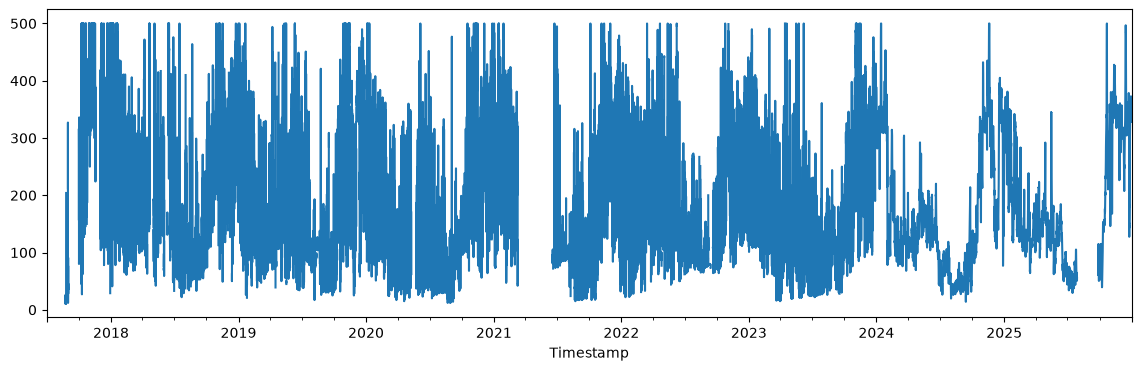

In [20]:
final_all = aqi.to_frame().join(weather, how="left")
print(final_all.shape)
print(final_all.isna().mean().mul(100).round(1))

# naya file, purani lodhi_hourly_with_weather.csv ko haath nahi lagana
final_all.to_csv("../data/aqi_hourly_with_weather.csv")

final_all["AQI"].plot(figsize=(14, 4))

In [21]:
# variant a: 2024-25 ka aqi seedha hourly pm se (rolling nahi)
si25 = np.interp(fin["PM2.5 (ug/m3)"], [0, 30, 60, 90, 120, 250, 380], [0, 50, 100, 200, 300, 400, 500])
si10 = np.interp(fin["PM10 (ug/m3)"], [0, 50, 100, 250, 350, 430, 510], [0, 50, 100, 200, 300, 400, 500])
fin["AQI_hourly"] = np.fmax(si25, si10)

# variant b: purane aqi ko 24 ghante ke rolling mean se smooth
old_h = old_long["value"].reindex(pd.date_range(old_long.index.min(), old_long.index.max(), freq="1h"))
old_smooth = old_h.rolling(24, min_periods=16).mean()

In [22]:
def stats(s):
    c1 = s.diff().abs()
    c24 = s.diff(24).abs()
    return pd.DataFrame({"mean": s.groupby(s.index.year).mean(),
                         "1h_change": c1.groupby(c1.index.year).mean(),
                         "24h_change": c24.groupby(c24.index.year).mean()})

print("purana original"); print(stats(old_h).round(1))
print("purana smooth (24h)"); print(stats(old_smooth).round(1))
print("naya rolling wala (jo abhi use kiya)"); print(stats(fin["AQI"]).round(1))
print("naya hourly wala"); print(stats(fin["AQI_hourly"]).round(1))

purana original
       mean  1h_change  24h_change
2017  304.7       28.0        66.8
2018  203.7       24.3        58.7
2019  182.6       23.4        62.8
2020  156.0       22.3        54.5
2021  194.8       19.8        52.7
2022  178.6       21.7        54.0
2023  170.9       20.4        53.2
purana smooth (24h)
       mean  1h_change  24h_change
2017  306.9        2.9        46.1
2018  204.8        2.4        35.9
2019  182.0        2.6        38.1
2020  155.1        2.3        33.1
2021  196.7        2.2        32.5
2022  179.4        2.2        32.1
2023  171.7        2.2        33.9
naya rolling wala (jo abhi use kiya)
            mean  1h_change  24h_change
Timestamp                              
2024       165.1        2.1        28.9
2025       190.3        2.1        31.4
naya hourly wala
            mean  1h_change  24h_change
Timestamp                              
2024       166.3       21.1        52.3
2025       188.8       22.2        51.8


In [24]:
# purana aqi (jaisa hai waisa) + 2024-25 ka hourly wala aqi
a_old = old_long["value"].rename("AQI")
a_new = fin["AQI_hourly"].rename("AQI")
aqi2 = pd.concat([a_old, a_new]).sort_index()
aqi2 = aqi2[~aqi2.index.duplicated(keep="first")]

# poora hourly index, jahan data nahi wahan nan
aqi2 = aqi2.reindex(pd.date_range(aqi2.index.min(), aqi2.index.max(), freq="1h"))
aqi2.index.name = "Timestamp"

# weather jodo aur save karo
final_v2 = aqi2.to_frame().join(weather, how="left")
print(final_v2.shape, final_v2["AQI"].isna().mean().round(3))
final_v2.to_csv("../data/aqi_hourly_v2.csv")

(74544, 7) 0.197


In [25]:
print(stats(final_v2["AQI"]).round(1))

            mean  1h_change  24h_change
Timestamp                              
2017       304.7       28.0        66.8
2018       203.7       24.3        58.7
2019       182.6       23.4        62.8
2020       156.0       22.3        54.5
2021       194.8       19.8        52.7
2022       178.6       21.7        54.0
2023       170.9       20.4        53.2
2024       166.3       21.1        52.3
2025       188.8       22.2        51.8
